> **3.1 Task 1: Bijection Learning**
> 
> Each sequence is derived from a new random bijection $\pi : \{1, \dots, V\} \to \{1, \dots, V\}$ with $V = 20$. At position $k$, the model has observed $k - 1$ distinct input–output pairs and must predict $\pi(x_k)$. Because inputs never repeat, the Bayes-optimal posterior over $\pi(x_k)$ is uniform over the $V - k + 1$ unseen values.
> 
> **Bayesian ground truth.** Let $O_{k-1}$ be observed outputs. Then
> 
> $$p(\pi(x_k) = y \mid \text{context}) = \begin{cases} \frac{1}{V-k+1}, & y \notin O_{k-1}, \\ 0, & y \in O_{k-1}, \end{cases}$$
> 
> with entropy $H_{\text{Bayes}}(k) = \log_2(V - k + 1)$.
> 
> **Evaluation.** We compute MAE over a held-out set of 2,000 bijections. Because $20! \approx 2.4 \times 10^{18}$ possible bijections exist and training uses only $10^5$ samples, no bijection is seen twice; the task enforces true hypothesis elimination.
> 
> **Sequence format.** Each training example is tokenized as
> 
> $$[x_1, y_1, \text{SEP}, x_2, y_2, \text{SEP}, \dots, x_{19}, \text{SEP}],$$
> 
> with teacher forcing at every $y_k$ position.


Let's build the dataset.

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from tqdm.autonotebook import tqdm

# --- 1. DATASET ---
class BijectionTask1(Dataset):
    def __init__(self, mappings, V=20):
        """
        mappings: A pre-generated tensor of shape (num_samples, V)
                  containing the specific bijections for this dataset.
        """
        self.mappings = mappings
        self.num_samples = mappings.shape[0]
        self.V = V
        self.staircase_entropy = torch.tensor([np.log2(V - k) for k in range(V - 1)], dtype=torch.float)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 1. Fetch the exact 'Secret Rule' assigned to this sample
        # We put it in a 1-indexed tensor so we can look up y = mapping[x] easily
        mapping = torch.empty(self.V + 1, dtype=torch.long)
        mapping[1:] = self.mappings[idx]
        
        # 2. Randomize the presentation order of x
        x_order = torch.randperm(self.V)[:self.V - 1] + 1
        y_order = mapping[x_order]
        
        # 3. Interleave [x, y, SEP]
        seq = torch.zeros((self.V - 1) * 3, dtype=torch.long)
        seq[0::3] = x_order
        seq[1::3] = y_order
        # seq[2::3] is already 0 (SEP token)
        
        return {
            "input_ids": seq[:-1],
            "labels": seq[1:],
            "staircase": self.staircase_entropy
        }

# --- Utility to Generate Unseen Splits ---
def generate_disjoint_bijections(num_train, num_test, V=20):
    """
    Generates permutations for Train and Test simultaneously to guarantee
    we can track exactly what the model is learning.
    """
    total_needed = num_train + num_test
    # A fast way to generate millions of unique random permutations in PyTorch
    rand_vals = torch.rand(total_needed, V)
    all_mappings = torch.argsort(rand_vals, dim=1) + 1
    
    train_mappings = all_mappings[:num_train]
    test_mappings = all_mappings[num_train:]
    return train_mappings, test_mappings

# --- Verification ---
# Generate a tiny dummy split for verification
dummy_train, dummy_test = generate_disjoint_bijections(num_train=10, num_test=2, V=20)
task1_data = BijectionTask1(mappings=dummy_train, V=20)
first_sample = task1_data[0]

print("Sequence structure:", first_sample['input_ids'].tolist())
print("Staircase Entropy (bits per step):", [round(e, 3) for e in first_sample['staircase'].tolist()])

# --- Dataset Shape Analysis ---
print(f"Number of samples in train dataset: {len(task1_data)}")
print(f"Length of a single sequence (L): {first_sample['input_ids'].shape[0]} tokens")
print(f"Number of prediction steps (k): {first_sample['staircase'].shape[0]} steps")

Sequence structure: [17, 10, 0, 5, 18, 0, 15, 12, 0, 11, 6, 0, 7, 15, 0, 10, 9, 0, 9, 3, 0, 8, 14, 0, 2, 20, 0, 1, 1, 0, 3, 8, 0, 14, 5, 0, 16, 16, 0, 18, 13, 0, 4, 11, 0, 19, 7, 0, 20, 4, 0, 13, 19, 0, 6, 2]
Staircase Entropy (bits per step): [4.322, 4.248, 4.17, 4.087, 4.0, 3.907, 3.807, 3.7, 3.585, 3.459, 3.322, 3.17, 3.0, 2.807, 2.585, 2.322, 2.0, 1.585, 1.0]
Number of samples in train dataset: 10
Length of a single sequence (L): 56 tokens
Number of prediction steps (k): 19 steps


C:\Temp\ipykernel_7040\2295817243.py:6: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


### Dataset Dimensions & Metadata

1.  **`input_ids` shape: `[56]`**
    *   **Why 56?** We have 19 pairs. Each pair is 3 tokens (`x`, `y`, `SEP`). $19 \times 3 = 57$. We remove the last token (`SEP`) because there is nothing to predict after it. So, $57 - 1 = 56$.
2.  **`labels` shape: `[56]`**
    *   This is the same length as `input_ids`. It is shifted right by 1, so the model learns to predict the "next" token at every position.
3.  **`staircase` shape: `[19]`**
    *   This contains the 19 levels of uncertainty. 
    *   **Mapping:** The model's entropy at `input_ids` indices **0, 3, 6, 9...** (the positions of $x_1, x_2, x_3...$) should match these 19 values.

---

### 1. The Architecture (from Page 8, Section 3.5)

> **Bijection transformer (2.67M):** 6 layers, 6 heads, $d_{model} = 192$, $d_{ffn} = 768$.
> 
> Both use learned token embeddings, learned absolute positional embeddings, pre-norm residual blocks, and standard multi-head self-attention.

### 2. The Training Protocol (from Page 9, Section 3.6)

> **Optimization.** AdamW with $\beta_1 = 0.9, \beta_2 = 0.999$, weight decay 0.01, gradient clipping at 1.0. Batch size is 64 for all tasks.
> 
> **Learning rates and training steps.**
> * **Bijections:** constant $10^{-3}$ for 150k steps.
> 
> **Data sampling.** Every batch draws fresh bijections or fresh HMMs; sequences never repeat.
> 
> **Teacher forcing.** Cross-entropy loss is applied at each supervised prediction position.

In [2]:
# --- HYPERPARAMETERS (Section 3.5 & 3.6) ---
V = 20
VOCAB_SIZE = 21   # 1-20 + SEP token (0)
D_MODEL = 192
NHEAD = 6
NUM_LAYERS = 6
D_FFN = 768
MAX_SEQ_LEN = 56  # (19 pairs * 3 tokens) - 1

BATCH_SIZE = 64
LR = 1e-3         # OG: 1e-3
STEPS = 150000      # OG: 150k 
MONITOR_INTERVAL = 100

TEST_SAMPLES = 2000 # As per paper for the evaluation

WEIGHT_DECAY = 0.01
CLIP = 1.0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- 2. MODEL DEFINITION ---
class BijectionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.pos_embedding = nn.Parameter(torch.zeros(1, MAX_SEQ_LEN, D_MODEL))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=NHEAD, dim_feedforward=D_FFN,
            dropout=0.0, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=NUM_LAYERS, enable_nested_tensor=False
        )
        self.ln_f = nn.LayerNorm(D_MODEL)
        self.head = nn.Linear(D_MODEL, VOCAB_SIZE, bias=False)

    def forward(self, x):
        b, t = x.size()
        x = self.token_embedding(x) + self.pos_embedding[:, :t, :]
        mask = torch.triu(torch.ones(t, t, device=x.device) * float('-inf'), diagonal=1)
        x = self.transformer(x, mask=mask, is_causal=True)
        return self.head(self.ln_f(x))

# --- 3. EXPERIMENTAL SETUP (Strict Split) ---
print(f"Pre-generating disjoint Train ({STEPS * BATCH_SIZE}) and Test ({TEST_SAMPLES}) splits...")
train_mappings, test_mappings = generate_disjoint_bijections(num_train=STEPS * BATCH_SIZE, num_test=TEST_SAMPLES, V=V)

train_dataset = BijectionTask1(mappings=train_mappings, V=V)
# We will use this test_dataset in Cell 3 later!
test_dataset = BijectionTask1(mappings=test_mappings, V=V) 

loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

model = BijectionTransformer().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999), fused=torch.cuda.is_available())

def get_predictive_entropy(logits):
    probs = F.softmax(logits, dim=-1)
    log_probs = F.log_softmax(logits, dim=-1)
    return -(probs * log_probs).sum(dim=-1) / np.log(2)

Y_POSITIONS = torch.arange(0, MAX_SEQ_LEN, 3, device=DEVICE)

# --- 4. TRAINING LOOP ---
print(f"Starting training on {DEVICE}...")
model.train()

pbar = tqdm(loader, total=STEPS, desc="Training")
for step, batch in enumerate(pbar):
    if step >= STEPS: break
    
    inputs = batch['input_ids'].to(DEVICE, non_blocking=True)
    targets = batch['labels'].to(DEVICE, non_blocking=True)
    
    logits = model(inputs)
    
    loss = F.cross_entropy(logits[:, Y_POSITIONS, :].reshape(-1, VOCAB_SIZE), targets[:, Y_POSITIONS].reshape(-1))
    
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
    optimizer.step()

    # --- MONITORING ---
    if step % MONITOR_INTERVAL == 0:
        with torch.no_grad():
            ideal_staircase = batch['staircase'].to(DEVICE, non_blocking=True)[0]
            model_entropy = get_predictive_entropy(logits[0, Y_POSITIONS, :])
            mae = torch.abs(model_entropy - ideal_staircase).mean().item()
            pbar.set_postfix({"Loss": f"{loss.item():.4f}", "MAE (bits)": f"{mae:.4f}"})

print("Training Complete.")

Pre-generating disjoint Train (9600000) and Test (2000) splits...
Starting training on cuda...


Training: 100%|██████████| 150000/150000 [2:34:56<00:00, 16.14it/s, Loss=2.2305, MAE (bits)=0.0068]  

Training Complete.


In [17]:
import os

# Create a directory to save the model
os.makedirs("saved_models", exist_ok=True)

# Save only the model weights (best practice)
save_path = "saved_models/bijection_transformer.pth"
torch.save(model.state_dict(), save_path)

print(f"Model weights successfully saved to: {save_path}")

Model weights successfully saved to: saved_models/bijection_transformer.pth


In [18]:
import torch
import torch.nn as nn

# 1. Define the necessary Hyperparameters
VOCAB_SIZE = 21 
D_MODEL = 192
NHEAD = 6
NUM_LAYERS = 6
D_FFN = 768
MAX_SEQ_LEN = 56 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Re-define the Model Architecture
class BijectionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.pos_embedding = nn.Parameter(torch.zeros(1, MAX_SEQ_LEN, D_MODEL))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=NHEAD, dim_feedforward=D_FFN,
            dropout=0.0, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=NUM_LAYERS, enable_nested_tensor=False
        )
        self.ln_f = nn.LayerNorm(D_MODEL)
        self.head = nn.Linear(D_MODEL, VOCAB_SIZE, bias=False)

    def forward(self, x):
        b, t = x.size()
        x = self.token_embedding(x) + self.pos_embedding[:, :t, :]
        # Causal mask ensures it only attends to previous tokens
        mask = torch.triu(torch.ones(t, t, device=x.device) * float('-inf'), diagonal=1)
        x = self.transformer(x, mask=mask, is_causal=True)
        return self.head(self.ln_f(x))

# 3. Instantiate and Load the Weights
model = BijectionTransformer().to(DEVICE)

# map_location ensures it loads properly whether you have a GPU right now or not
model.load_state_dict(torch.load("saved_models/bijection_transformer.pth", map_location=DEVICE, weights_only=True))

# 4. Set to Evaluation mode (crucial for inference!)
model.eval() 

print("Model successfully loaded and ready for inference!")

Model successfully loaded and ready for inference!


Evaluating on 2000 strictly unseen bijections...
Final Test MAE: 0.0097 bits
Plot successfully saved to: results\bijection_task1_staircase.pdf


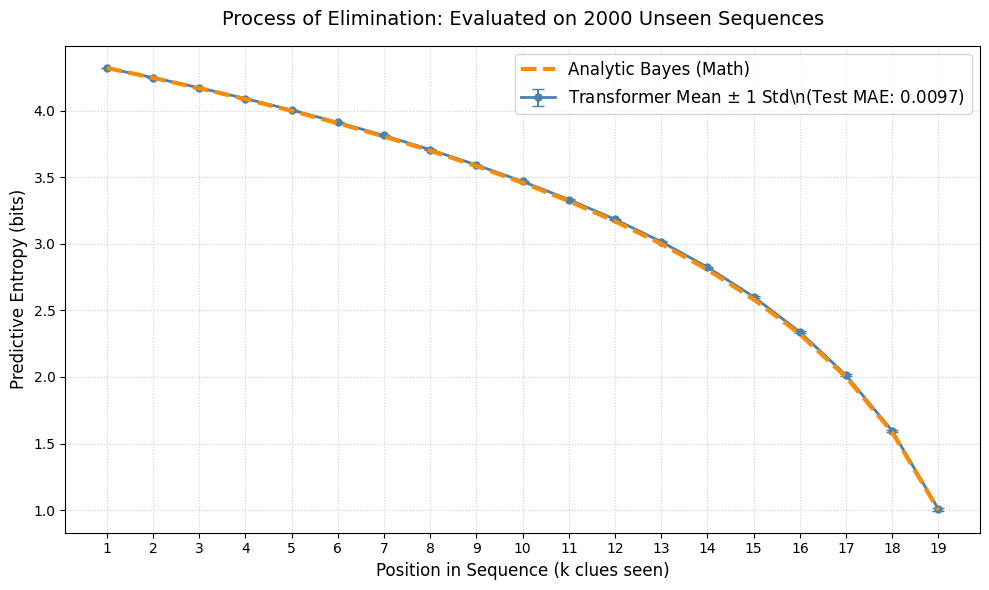

In [19]:
import os
import matplotlib.pyplot as plt

# --- 1. EVALUATION (Full Test Set) ---
print(f"Evaluating on {len(test_dataset)} strictly unseen bijections...")

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=0)

model.eval()
total_mae = 0.0
all_predictions = [] 

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['input_ids'].to(DEVICE)
        ideal_staircase = batch['staircase'].to(DEVICE)
        
        logits = model(inputs)
        model_entropy = get_predictive_entropy(logits[:, Y_POSITIONS, :])
        
        batch_mae = torch.abs(model_entropy - ideal_staircase).mean().item()
        total_mae += batch_mae * inputs.size(0) 
        
        all_predictions.append(model_entropy.cpu())

all_predictions_tensor = torch.cat(all_predictions, dim=0)

mean_entropy = all_predictions_tensor.mean(dim=0).numpy()
std_entropy = all_predictions_tensor.std(dim=0).numpy()

final_mae = total_mae / len(test_dataset)
print(f"Final Test MAE: {final_mae:.4f} bits")

# --- 2. PLOT THE STATISTICAL STAIRCASE ---
ideal_staircase_np = test_dataset[0]['staircase'].numpy()
k_steps = np.arange(1, len(ideal_staircase_np) + 1)

plt.figure(figsize=(10, 6))

plt.plot(k_steps, ideal_staircase_np, 
         label="Analytic Bayes (Math)", 
         color='darkorange', linestyle='--', linewidth=3, zorder=3)

plt.errorbar(k_steps, mean_entropy, yerr=std_entropy, 
             label=fr"Transformer Mean $\pm$ 1 Std\n(Test MAE: {final_mae:.4f})", 
             color='steelblue', marker='o', linewidth=2, markersize=5, 
             capsize=4, elinewidth=1.5, zorder=2)

plt.fill_between(k_steps, mean_entropy - std_entropy, mean_entropy + std_entropy, 
                 color='steelblue', alpha=0.2, zorder=1)

plt.title(f"Process of Elimination: Evaluated on {len(test_dataset)} Unseen Sequences", fontsize=14, pad=15)
plt.xlabel("Position in Sequence (k clues seen)", fontsize=12)
plt.ylabel("Predictive Entropy (bits)", fontsize=12)
plt.xticks(k_steps)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()

# --- 3. SAVE THE PLOT ---
# Create the results directory if it doesn't exist
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

# Save as PDF
file_path = os.path.join(output_dir, "bijection_task1_staircase.pdf")
plt.savefig(file_path, format='pdf', bbox_inches='tight')
print(f"Plot successfully saved to: {file_path}")

# Display the plot in the notebook
plt.show()

The paper claims that in the very first layer, the Transformer creates a literal geometric coordinate system. It takes the 20 possible symbols and spaces them out so they are at 90-degree angles (orthogonal) to each other, creating a clean "Hypothesis Frame."

### From Pages 14-15 (Section 5.1: Layer 0 Creates the Hypothesis Frame)

> The computation begins with a structural operation: Layer 0 attention constructs the *hypothesis space* in which all subsequent inference takes place. Keys at this layer form an approximately orthogonal basis over input tokens (Figure 16), providing a coordinate system over which posterior mass can be represented and manipulated. We measure orthogonality via mean absolute off-diagonal cosine similarity between key vectors.

Plot successfully saved to: results\fig18b_value_manifold.pdf


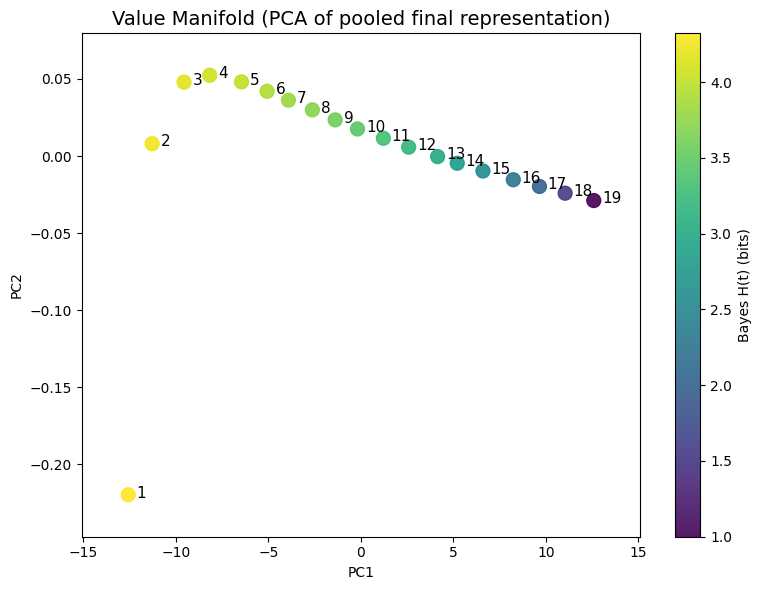

In [29]:
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SETUP HOOK ---
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if isinstance(output, tuple):
            activations[name] = output[0].detach()
        else:
            activations[name] = output.detach()
    return hook

# The caption specifies "block attention output"
h1 = model.transformer.layers[-1].self_attn.register_forward_hook(get_activation('block_attn'))

# --- 2. EXTRACT AND POOL DATA ---
# Pass a large batch to get a stable, clean average
pool_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)
batch = next(iter(pool_loader))
inputs = batch['input_ids'].to(DEVICE)

model.eval()
with torch.no_grad():
    _ = model(inputs)

h1.remove() # Clean up hook

# Extract predictions positions. Shape: [Batch(1000), Steps(19), D_MODEL(192)]
attn_out = activations['block_attn'][:, Y_POSITIONS, :].cpu().numpy() 

# *** THE CRITICAL STEP ***
# Average across the batch dimension (axis=0) to marginalize out token identities.
# This leaves exactly 19 points (one pure representation for each prediction step)
pooled_outputs = attn_out.mean(axis=0) # Shape: [19, D_MODEL]

# Calculate the analytic entropy for the 19 steps to color the points
# H(k) = log2(20 - k + 1) for k in 1..19
steps = np.arange(1, 20)
analytic_entropies = np.log2(20 - steps + 1)

# --- 3. PCA AND PLOTTING ---
# Fit PCA directly on the 19 pooled points
pca = PCA(n_components=2)
proj = pca.fit_transform(pooled_outputs) # Shape: [19, 2]

plt.figure(figsize=(8, 6))
# 'viridis' maps high values (4.3 bits) to Yellow and low (1.0 bits) to Purple, matching the paper
sc = plt.scatter(proj[:, 0], proj[:, 1], c=analytic_entropies, cmap='viridis', s=100, alpha=0.9)

# Annotate points 1 through 19
for i, txt in enumerate(steps):
    plt.annotate(str(txt), (proj[i, 0], proj[i, 1]), 
                 fontsize=11, xytext=(6, -2), textcoords="offset points")

plt.title("Value Manifold (PCA of pooled final representation)", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")

cbar = plt.colorbar(sc)
cbar.set_label("Bayes H(t) (bits)")

plt.margins(0.1) # Give a little padding so text doesn't hit borders
plt.tight_layout()

import os

# --- SAVE THE PLOT ---
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

file_path_18b = os.path.join(output_dir, "fig18b_value_manifold.pdf")
plt.savefig(file_path_18b, format='pdf', bbox_inches='tight', dpi=300)
print(f"Plot successfully saved to: {file_path_18b}")

plt.show()

Plot successfully saved to: results\fig17_qk_alignment.pdf


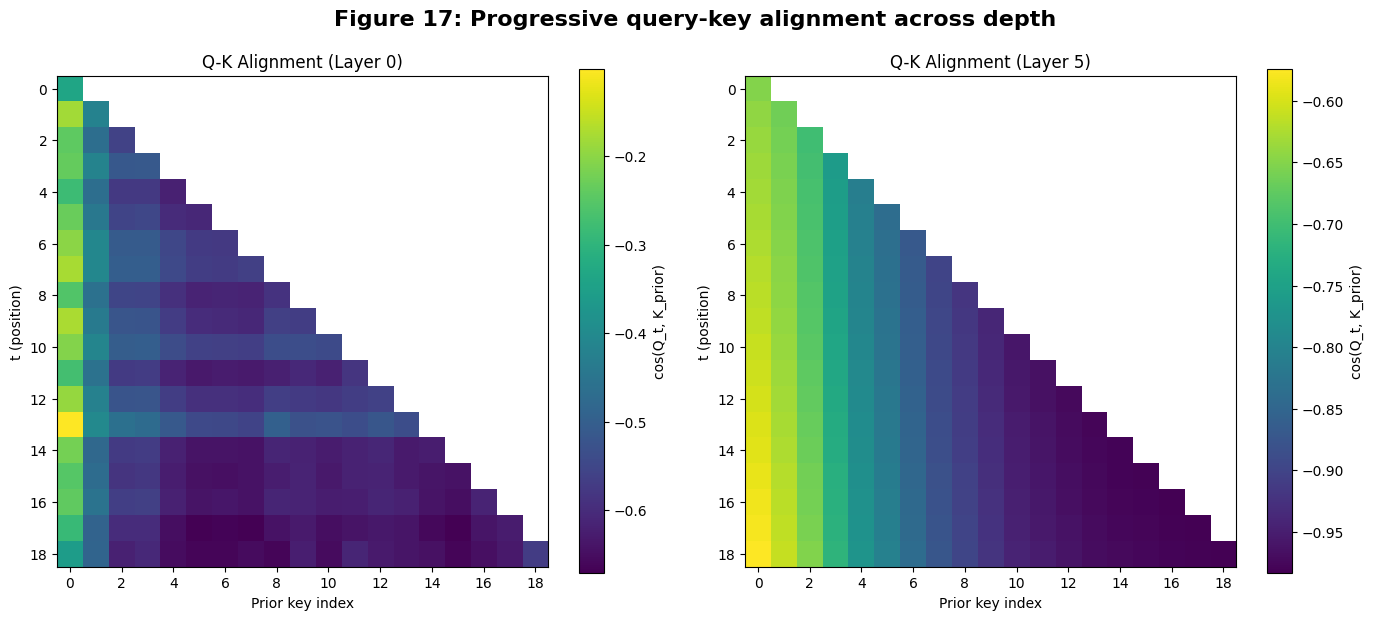

In [33]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. SETUP HOOKS TO GRAB ATTENTION INPUTS ---
captured_x = {}

def get_pre_attn_hook(name):
    def hook(module, args):
        captured_x[name] = args[0].detach() 
    return hook

# Hook Layer 0 and Layer 5
h0 = model.transformer.layers[0].self_attn.register_forward_pre_hook(get_pre_attn_hook('L0'))
h5 = model.transformer.layers[-1].self_attn.register_forward_pre_hook(get_pre_attn_hook('L5'))

# --- 2. RUN A BATCH OF DATA ---
batch_size = 500
pool_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
batch = next(iter(pool_loader))
inputs = batch['input_ids'].to(DEVICE)

model.eval()
with torch.no_grad():
    _ = model(inputs)

h0.remove()
h5.remove()

# --- 3. CORRECT MULTI-HEAD QK MATH ---
@torch.no_grad()
def compute_multihead_qk_cossim(layer_idx, x_input):
    attn = model.transformer.layers[layer_idx].self_attn
    
    W_q, W_k, _ = attn.in_proj_weight.chunk(3)
    b_q, b_k, _ = attn.in_proj_bias.chunk(3) if attn.in_proj_bias is not None else (None, None, None)
        
    Q = F.linear(x_input, W_q, b_q)
    K = F.linear(x_input, W_k, b_k)
    
    # Slice out ONLY the 19 prediction positions
    Q_pred = Q[:, Y_POSITIONS, :] # [Batch, 19, 192]
    K_pred = K[:, Y_POSITIONS, :] 
    
    B, L, D = Q_pred.shape
    HEAD_DIM = D // NHEAD
    
    # Reshape for multi-head: [Batch, NHEAD, SeqLen, HEAD_DIM]
    Q_mh = Q_pred.view(B, L, NHEAD, HEAD_DIM).transpose(1, 2)
    K_mh = K_pred.view(B, L, NHEAD, HEAD_DIM).transpose(1, 2)
    
    # Normalize Q and K ALONG THE HEAD DIMENSION to compute true Cosine Similarity
    Q_norm = F.normalize(Q_mh, p=2, dim=-1)
    K_norm = F.normalize(K_mh, p=2, dim=-1)
    
    # Batch matrix multiplication per head: [Batch, NHEAD, 19, 19]
    cos_sim = torch.matmul(Q_norm, K_norm.transpose(-1, -2))
    
    # 1. Average across the 6 heads -> [Batch, 19, 19]
    mean_heads = cos_sim.mean(dim=1)
    
    # 2. Average across the batch -> [19, 19]
    mean_batch = mean_heads.mean(dim=0).cpu().numpy()
    
    # Apply a Causal Mask (upper triangle becomes NaN/white)
    mask = np.triu(np.ones_like(mean_batch, dtype=bool), k=1)
    mean_batch[mask] = np.nan
    
    return mean_batch

sim0 = compute_multihead_qk_cossim(0, captured_x['L0'])
sim5 = compute_multihead_qk_cossim(-1, captured_x['L5'])

# --- 4. PLOT EXACTLY LIKE FIGURE 17 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cmap = plt.cm.viridis.copy()
cmap.set_bad('white', 1.) 

# Plot Layer 0 (Auto-scaling colorbar as you requested)
im0 = axes[0].imshow(sim0, cmap=cmap)
axes[0].set_title("Q-K Alignment (Layer 0)", fontsize=12)
axes[0].set_xlabel("Prior key index")
axes[0].set_ylabel("t (position)")
axes[0].set_xticks(np.arange(0, 19, 2))
axes[0].set_yticks(np.arange(0, 19, 2))
fig.colorbar(im0, ax=axes[0], label="cos(Q_t, K_prior)")

# Plot Layer 5 (Auto-scaling colorbar)
im5 = axes[1].imshow(sim5, cmap=cmap)
axes[1].set_title("Q-K Alignment (Layer 5)", fontsize=12)
axes[1].set_xlabel("Prior key index")
axes[1].set_ylabel("t (position)")
axes[1].set_xticks(np.arange(0, 19, 2))
axes[1].set_yticks(np.arange(0, 19, 2))
fig.colorbar(im5, ax=axes[1], label="cos(Q_t, K_prior)")

plt.suptitle("Figure 17: Progressive query-key alignment across depth", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.88)

# --- SAVE THE PLOT ---
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)
file_path_17 = os.path.join(output_dir, "fig17_qk_alignment.pdf")
plt.savefig(file_path_17, format='pdf', bbox_inches='tight', dpi=300)
print(f"Plot successfully saved to: {file_path_17}")

plt.show()